<a href="https://colab.research.google.com/github/kousheel05/TASK_AIML-/blob/main/Anomaly_Detection_(self_learning).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Anomaly Detection

Anomaly Detection is a Machine Learning technique used to identify unusual data points, events, or observations that differ significantly from normal behavior.

In simple words:

It finds data that doesn't look like the rest of the data.

Why do we use Anomaly Detection?

Examples:

Credit card fraud

Network intrusion

Manufacturing defects

Medical disease detection

Fake reviews

Server failures

Example

Suppose a bank has 10 lakh transactions.

Normal transactions:

₹100
₹250
₹500
₹1200

Suddenly

₹9,50,000 transaction at 3 AM

This is detected as an anomaly.

Popular Algorithms

Isolation Forest

Local Outlier Factor (LOF)

One-Class SVM

DBSCAN

Autoencoders (Deep Learning)

(Isolation Forest)

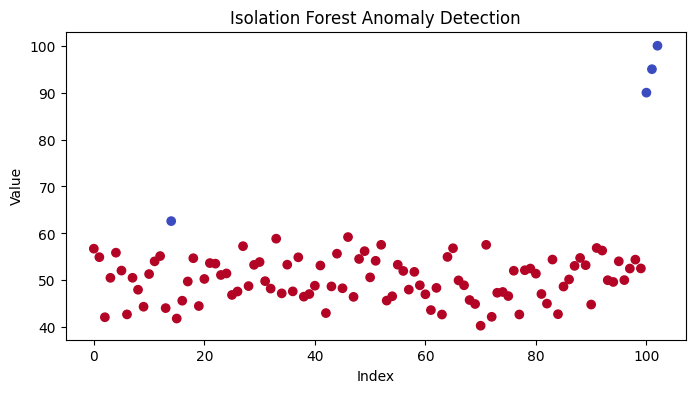

In [4]:
import numpy as np
from sklearn.ensemble import IsolationForest
import matplotlib.pyplot as plt

# Normal data
normal_data = np.random.normal(50, 5, 100)

# Anomalies
anomalies = np.array([90, 95, 100])

# Combine data
X = np.concatenate((normal_data, anomalies)).reshape(-1, 1)

# Train Isolation Forest
model = IsolationForest(
    contamination=0.03,
    random_state=42
)

model.fit(X)

# Predict
predictions = model.predict(X)

# Plot
plt.figure(figsize=(8,4))
plt.scatter(range(len(X)), X, c=predictions, cmap="coolwarm")
plt.xlabel("Index")
plt.ylabel("Value")
plt.title("Isolation Forest Anomaly Detection")
plt.show()

Local Outlier Factor (LOF)

Definition

Local Outlier Factor (LOF) is an unsupervised anomaly detection algorithm that identifies anomalies by comparing the local density of a data point with the density of its neighboring points.

In [5]:
from sklearn.neighbors import LocalOutlierFactor
import numpy as np

X = np.array([[1],[2],[2],[3],[2],[100]])

lof = LocalOutlierFactor(n_neighbors=2)

pred = lof.fit_predict(X)

print(pred)

[-1  1  1 -1  1 -1]


/usr/local/lib/python3.12/dist-packages/sklearn/neighbors/_lof.py:322: UserWarning: Duplicate values are leading to incorrect results. Increase the number of neighbors for more accurate results.
  warnings.warn(


One-Class SVM

Definition

One-Class Support Vector Machine (One-Class SVM) is an unsupervised anomaly detection algorithm that learns the boundary around normal data. Any point outside this boundary is classified as an anomaly.

In [6]:
from sklearn.svm import OneClassSVM
import numpy as np

X = np.array([[1],[2],[2],[3],[2],[100]])

model = OneClassSVM(gamma='auto')

model.fit(X)

pred = model.predict(X)

print(pred)

[ 1  1  1 -1  1  1]


DBSCAN

Definition

DBSCAN (Density-Based Spatial Clustering of Applications with Noise) is a clustering algorithm that groups closely packed points together and labels points that do not belong to any dense cluster as noise (anomalies).

In [7]:
from sklearn.cluster import DBSCAN
import numpy as np

X = np.array([[1],[2],[2],[3],[2],[100]])

db = DBSCAN(eps=3, min_samples=2)

labels = db.fit_predict(X)

print(labels)

[ 0  0  0  0  0 -1]


Autoencoders (Deep Learning)

Definition

An Autoencoder is a type of neural network that learns to compress and reconstruct input data. It is commonly used for anomaly detection by learning the patterns of normal data.

In [8]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

model = Sequential([
    Dense(16, activation='relu', input_shape=(4,)),
    Dense(8, activation='relu'),
    Dense(16, activation='relu'),
    Dense(4, activation='sigmoid')
])

model.compile(optimizer='adam', loss='mse')

print(model.summary())

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           144 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 4)              │            68 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 428 (1.67 KB)

 Trainable params: 428 (1.67 KB)

 Non-trainable params: 0 (0.00 B)

None
